# Mini Proyecto Deep Learning - Start-Up basada en IA
#### Máster Universitario en Ciencia de Datos - UV

### Adrián Carrasco Alcalá y Clara Montalvá Barcenilla


## Descripción

El usuario dibuja su edad y un animal, añadiendo opcionalmente una pequeña descripción del mismo y del contexto deseado para la historia. Se crea tanto un dibujo mejorado del animal pensado para colorear como un cuento interactivo que lo tiene como protagonista y que va acompañado de dibujos y de una voz que narra la historia.

#### <u>Inputs</u>
- Dibujo con la edad del niño
- Dibujo de un animal
- Pequeña descripción del animal y planteamiento de la historia hecha por el usuario (opcional).

#### <u>Modelos</u>
- Red Neuronal Convolucional (CNN): Identificar la edad dibujada (entrenada con el conjunto MNIST).
- CLIP: Detectar los animales a partir de los garabatos.
- ControlNet: Mejorar los dibujos de los animales.
- VAE/ControlNet: Crear un dibujo del animal para colorear.
- API Gemini: Generar las partes de la historia.
- Suno: Generar la voz del narrador que lee la historia.
- Stable Difussion: Crear los dibujos a partir de las partes de la historia.
- ControlNet: Combinar los dibujos creados a partir de la historia con los de los animales mejorados.

#### <u>Outputs</u>
- Texto con la historia completa divida en partes, con peticiones de dibujos entre ellas.
- Audio con la voz del narrador contando la historia.
- Imágenes con dibujos creados a partir de la historia y que la complementan.
- Imagen con un dibujo mejorado del animal pintado por el usuario, preparado para colorearlo. 

### Diagrama con modelos de IA

<img src="Diagrama_Proyecto_DL.jpg" width="900" height="500">


## Aplicación de los modelos

### Red Neuronal Convolucional (CNN) para la detección de la edad

Utilizamos una red neuronal entrenada con el conjunto de datos MNIST que sea capaz de identificar el número dibujado por el niño o el padre para clasificarlo en uno de los siguientes grupos de edad:
- 3-5 años
- 6-9 años
- 10-12 años

En primer lugar, abrimos la ventana de dibujo que pregunta por la edad.

In [2]:
import numpy as np
import tensorflow as tf
import cv2
import tkinter as tk
from PIL import Image, ImageDraw
from skimage.transform import resize

from modulos.AplicacionDibujo import AplicacionDibujo

In [3]:
root = tk.Tk()  # Creamos una ventana básica en blanco
app = AplicacionDibujo(root)

# Iniciar el bucle de la ventana (el código se detiene aquí hasta que se cierre la ventana)
root.mainloop()

if app.imagen_resultado is not None:
    print("La imagen ha sido guardada.")
    img = app.imagen_resultado
else:
    print("La ventana se cerró sin guardar la imagen.")

La imagen ha sido guardada.


Cargamos el modelo.

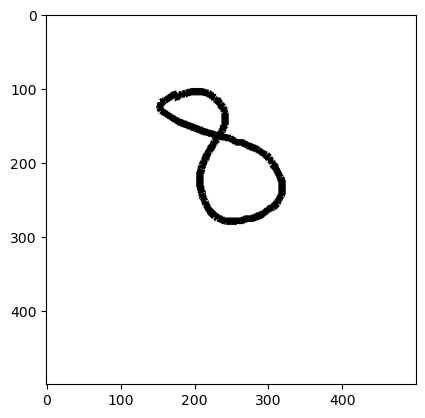

In [30]:
import matplotlib.pyplot as plt

plt.imshow(img)

In [4]:
modelo = tf.keras.models.load_model('modelos/CNN_edad.keras')

In [5]:
from modulos.edad import deteccion_edad

edad = deteccion_edad(img, modelo)

print("La edad del niño es:", edad)

La edad del niño es: 8


### Modelo Qwen3-VL para identificación y descripción del dibujo del animal

In [6]:
root = tk.Tk()  # Creamos una ventana básica en blanco
app = AplicacionDibujo(root, modo_edad=False)

# Iniciar el bucle de la ventana (el código se detiene aquí hasta que se cierre la ventana)
root.mainloop()

if app.imagen_resultado is not None:
    print("La imagen ha sido guardada.")
    img_animal = app.imagen_resultado
else:
    print("La ventana se cerró sin guardar la imagen.")

La imagen ha sido guardada.


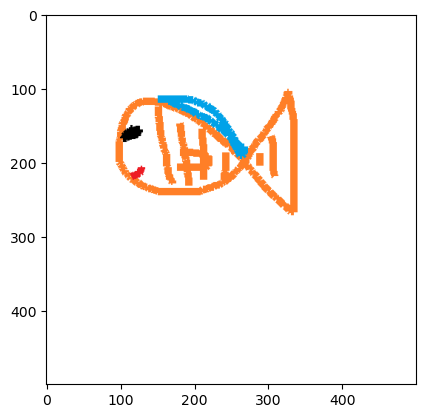

In [31]:
plt.imshow(img_animal)

In [14]:
from modulos import descripcion_dibujo

desc = descripcion_dibujo.descripcion(img_animal)

desc = desc[0].split("assistant")[1].strip()
desc_sep = desc.strip().split('\n')
animal = desc_sep[0].replace("Animal: ", "").strip()
descripcion = desc_sep[1].replace("Description: ", "").strip()

In [32]:
print("Animal:", animal)
print("Descripción:", descripcion)

Animal: Fish
Descripción: A cartoon fish with an orange body, a blue stripe across its back, a black eye, and a red mouth. It has a simple, stylized shape with a pointed tail.


### API Gemini para generación de la primera parte de la historia

In [17]:
from google import genai

In [18]:
# Leemos la clave API desde un archivo de texto
with open("clave.txt", "r", encoding="utf-8") as archivo:
    GEMINI_API_KEY = archivo.read()

In [20]:
cliente = genai.Client(api_key=GEMINI_API_KEY)

modelo = "gemini-3-flash-preview"
prompt = f'''Eres un experto escritor de cuentos infantiles en español. 
Escribe la primera parte de un cuento que tenga a un/una {animal} como protagonista de la historia. El/La {animal} tiene las siguientes características: {descripcion} (no es necesario que la descripción de ellas sea explícita).
La extensión de esta primera parte debe ser estrictamente de 3 párrafos.
La historia tendrá dos partes, por lo que la trama debe evolucionar rápido. Además, el cuento debe estar escrito específicamente para que lo entienda un niño de {edad} años, utilizando un vocabulario apropiado para esa etapa de desarrollo vital.
Debes tener en cuenta que el texto será leído por un narrador en voz alta, y que se generará una dibujo a partir de él, por lo que debe ser descriptivo y con pausas.
Por último, debe introducirse casi al final de esta primera parte de la historia a un segundo animal desconocido, del cual no se dé una descripción muy detallada para permitir que sea elegido libremente por el niño.
Añade un cuarto párrafo adicional que sea estrictamente una pregunta corta para el niño acerca de cuál es este nuevo animal (la pregunta debe estar en el tiempo verbal de la historia).'''

respuesta = cliente.models.generate_content(
    model = modelo, contents = prompt
)

cuento = respuesta.text

print(cuento)

Había una vez un pececito llamado Rayo que vivía en un arrecife lleno de colores. Su cuerpo era de un naranja brillante, tan intenso que se podía ver desde muy lejos, y llevaba una raya azul sobre su espalda como si fuera una pequeña medalla de velocidad. Con su ojo negro siempre atento y su boca roja siempre lista para saludar, Rayo movía su colita puntiaguda para nadar entre las burbujas. Era el pez más rápido de su grupo y siempre soñaba con vivir una gran aventura fuera de su hogar de coral.

Una mañana, Rayo decidió que era el momento de explorar lo que había más allá de la gran roca gris. Nadó con mucha fuerza, sintiendo cómo el agua fresca pasaba por sus costados mientras se alejaba de lo conocido. El paisaje cambió rápidamente: las plantas se volvieron más largas y el fondo del mar se llenó de una arena blanca y reluciente que parecía brillar. Rayo no tenía miedo, porque sabía que el océano estaba lleno de sorpresas maravillosas esperando a ser descubiertas por un pez tan valie

### Modelo T2S Edge API Microsoft para la generación de la voz del narrador

In [22]:
import asyncio
import os
from modulos.narrador import crear_audiolibro, reproducir_audio

if os.path.exists("cuento.mp3"):
    os.remove("cuento.mp3")

await crear_audiolibro(cuento)

In [ ]:
reproducir_audio("cuento.mp3")

### Modelo Qwen3-VL para identificación y descripción del dibujo del segundo animal

In [33]:
root = tk.Tk()  # Creamos una ventana básica en blanco
app = AplicacionDibujo(root, modo_edad=False)

# Iniciar el bucle de la ventana (el código se detiene aquí hasta que se cierre la ventana)
root.mainloop()

if app.imagen_resultado is not None:
    print("La imagen ha sido guardada.")
    img_animal_2 = app.imagen_resultado
else:
    print("La ventana se cerró sin guardar la imagen.")

La imagen ha sido guardada.


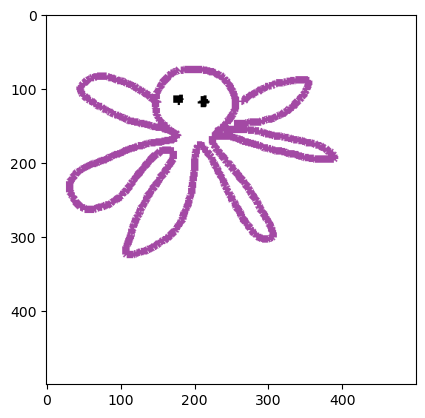

In [34]:
plt.imshow(img_animal_2)

In [37]:
desc_2 = descripcion_dibujo.descripcion(img_animal_2)

desc_2 = desc_2[0].split("assistant")[1].strip()
desc_sep_2 = desc_2.strip().split('\n')
animal_2 = desc_sep_2[0].replace("Animal: ", "").strip()
descripcion_2 = desc_sep_2[1].replace("Description: ", "").strip()

In [39]:
print("Animal:", animal_2)
print("Descripción:", descripcion_2)

Animal: Octopus
Descripción: A purple octopus with a round body, eight arms, and two small black eyes.


### API Gemini para generación de la segunda parte de la historia

In [ ]:
prompt_2 = f'''Eres un experto escritor de cuentos infantiles en español que va a generar la segunda y parte final de un cuento. 
La primera parte del cuento, que tenía a un/una {animal} como protagonista de la historia, era:
"{cuento}"
La respuesta del niño a la pregunta final de la primera parte es un/una {animal_2} con las siguientes características: {descripcion_2} (no es necesario que esta descripción aparezca explícita en la segunda parte).
Escribe la segunda parte del cuento. La extensión de esta segunda parte debe ser estrictamente de 3 párrafos.
Es la parte final de la historia, por lo que la trama debe cerrarse. Además, el cuento debe estar escrito específicamente para que lo entienda un niño de {edad} años, utilizando un vocabulario apropiado para esa etapa de desarrollo vital.
Debes tener en cuenta que el texto será leído por un narrador en voz alta, y que se generará una dibujo a partir de él, por lo que debe ser descriptivo y con pausas.
Por último, añade un cuarto párrafo adicional que tenga explícitamente la palabra "Moraleja:" seguida de una conclusión o moraleja sobre la historia para un niño de {edad} años (directamente, sin decir cosas como "Este cuento nos enseña...")'''

respuesta = cliente.models.generate_content(
    model = modelo, contents = prompt_2
)

cuento_2 = respuesta.text

print(cuento_2)

Aquel misterioso ser era un pulpo de color morado intenso, con un cuerpo redondito que parecía una suave burbuja flotando en las profundidades. Sus ocho brazos largos se movían ondulando con mucha calma, como si estuvieran bailando una música que solo él podía escuchar. Tenía dos ojitos negros, pequeños y brillantes, que miraban a Rayo con muchísima curiosidad y dulzura. El pulpo extendió uno de sus tentáculos con cuidado y tocó suavemente la arena, invitando al pececito naranja a acercarse sin miedo para jugar.

Rayo, que siempre había sido muy valiente, nadó rápidamente alrededor del pulpo, dejando una estela azul con su raya de velocidad. El pulpo, emocionado por tener un nuevo amigo, empezó a soltar pequeñas burbujas y a cambiar un poquito su color para mostrar lo feliz que estaba. Juntos exploraron los escondites de la arena blanca y descubrieron caracolas que brillaban como si fueran tesoros escondidos. Rayo se dio cuenta de que, aunque su nuevo amigo tenía muchos brazos y una fo

### Modelo T2S Edge API Microsoft para la generación de la voz del narrador

In [44]:
from modulos.narrador import crear_audiolibro

if os.path.exists("cuento_2.mp3"):
    os.remove("cuento_2.mp3")

await crear_audiolibro(cuento_2, archivo_salida = "cuento_2.mp3")

In [ ]:
reproducir_audio("cuento_2.mp3")